# Topic modeling

In [8]:
pip install spacy


Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
import spacy
from sklearn.feature_extraction.text import CountVectorizer


## Load data

In [10]:
df = pd.read_csv("../Local_csv/interventions_topics.csv")  

#Drop null or empty speeches
df = df[df["text"].notna() & (df["text"].str.strip() != "")]
df.head()

,text,gender,year,grupo,position
0,"Gracias, señora presidenta. Señorías, interven...",F,2003,Grupo Parlamentario Socialista,NaN
1,"Gracias, señora presidenta. El Bloque Nacional...",M,2003,Grupo Parlamentario Mixto,NaN
2,"Muchas gracias, señora presidenta. Mi grupo va...",M,2003,Grupo Parlamentario de Coalición Canaria,NaN
3,"Señora presidenta, señorías, arratsalde on, bu...",M,2003,Grupo Parlamentario Vasco (EAJ-PNV),NaN
4,"Ya he finalizado, señora presidenta, muchas gr...",M,2003,Grupo Parlamentario Vasco (EAJ-PNV),NaN


## Preprocess the text

In [11]:
nlp = spacy.load("es_core_news_sm")

def preprocess(text):
    doc = nlp(text.lower())
    tokens = [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]
    return " ".join(tokens)

# Apply preprocessing
df["clean_text"] = df["text"].apply(preprocess)


## Vectorize the clean text

In [12]:
vectorizer = CountVectorizer(max_df=0.95, min_df=5)
dtm = vectorizer.fit_transform(df["clean_text"])

## Run LDA to extract topics

In [13]:
from sklearn.decomposition import LatentDirichletAllocation

n_topics = 9  # You can tweak this
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(dtm)


LatentDirichletAllocation(n_components=9, random_state=42)

Before choseing the number of topics I tried all of them from 4 to 10 and finally stayed with 9 because it gave me: 
- Balance between detail and interpretability
- Clear thematic diversity (education, economy, war, gender, etc.)
- No over-fragmentation like in 10 topics

TOPIC MODEL with 4 topics
  Topic 1: año, gobierno, social, millón, política, euros, económico, empleo, medida, él
  Topic 2: señor, gobierno, él, guerra, seguridad, derecho, internacional, país, españa, español
  Topic 3: ley, grupo, enmienda, proyecto, parlamentario, él, comunidad, autónomo, gobierno, general
  Topic 4: señor, gobierno, partido, él, aplauso, españa, decir, presidente, español, país

TOPIC MODEL with 5 topics
  Topic 1: año, gobierno, social, millón, política, económico, euros, medida, público, empleo
  Topic 2: ley, grupo, derecho, él, señoría, persona, parlamentario, penal, gobierno, año
  Topic 3: ley, grupo, enmienda, proyecto, comunidad, autónomo, él, parlamentario, competencia, administración
  Topic 4: señor, gobierno, partido, aplauso, él, españa, decir, presidente, español, país
  Topic 5: señor, guerra, gobierno, internacional, país, españa, él, español, consejo, europeo

TOPIC MODEL with 6 topics
  Topic 1: año, gobierno, millón, público, euros, presupuesto, social, política, plan, él
  Topic 2: ley, grupo, derecho, él, señoría, persona, penal, parlamentario, gobierno, mujer
  Topic 3: ley, grupo, enmienda, proyecto, comunidad, autónomo, parlamentario, él, competencia, administración
  Topic 4: señor, gobierno, partido, aplauso, él, decir, presidente, españa, español, popular
  Topic 5: señor, guerra, gobierno, internacional, él, españa, país, español, irak, seguridad
  Topic 6: empleo, europeo, país, año, empresa, social, españa, gobierno, unión, política

TOPIC MODEL with 7 topics
  Topic 1: año, gobierno, millón, euros, presupuesto, público, plan, política, él, señor
  Topic 2: derecho, ley, él, persona, penal, mujer, señoría, delito, año, gobierno
  Topic 3: ley, comunidad, autónomo, proyecto, competencia, público, administración, él, gobierno, servicio
  Topic 4: señor, gobierno, partido, aplauso, él, decir, presidente, españa, español, señora
  Topic 5: guerra, señor, gobierno, internacional, país, españa, él, irak, español, seguridad
  Topic 6: social, empleo, año, empresa, país, gobierno, económico, política, españa, trabajador
  Topic 7: ley, grupo, enmienda, parlamentario, proyecto, él, general, señora, artículo, cámara

TOPIC MODEL with 8 topics
  Topic 1: año, gobierno, millón, euros, presupuesto, público, plan, política, económico, él
  Topic 2: derecho, ley, él, penal, mujer, persona, señoría, delito, año, violencia
  Topic 3: ley, comunidad, autónomo, competencia, público, administración, proyecto, él, servicio, gobierno
  Topic 4: señor, gobierno, partido, aplauso, él, decir, presidente, españa, señora, español
  Topic 5: guerra, señor, gobierno, internacional, irak, unidas, él, resolución, seguridad, español
  Topic 6: social, empleo, empresa, año, trabajador, laboral, pensión, gobierno, reforma, trabajo
  Topic 7: ley, grupo, enmienda, parlamentario, proyecto, él, general, señora, artículo, cámara
  Topic 8: europeo, unión, españa, país, europea, europa, política, gobierno, él, español

TOPIC MODEL with 9 topics
  Topic 1: año, millón, gobierno, euros, presupuesto, público, plan, política, social, económico
  Topic 2: derecho, ley, penal, él, mujer, persona, delito, señoría, año, violencia
  Topic 3: ley, comunidad, autónomo, proyecto, público, administración, competencia, servicio, gobierno, él
  Topic 4: señor, gobierno, partido, aplauso, él, presidente, decir, españa, señora, popular
  Topic 5: guerra, señor, gobierno, internacional, irak, unidas, resolución, él, seguridad, español
  Topic 6: social, empleo, año, empresa, trabajador, laboral, pensión, gobierno, reforma, trabajo
  Topic 7: grupo, ley, enmienda, parlamentario, proyecto, él, señora, cámara, general, artículo
  Topic 8: europeo, unión, españa, país, europea, europa, política, gobierno, él, español
  Topic 9: ley, educación, educativo, lengua, él, derecho, salud, catalán, centro, español

TOPIC MODEL with 10 topics
  Topic 1: año, millón, gobierno, público, presupuesto, euros, política, social, económico, medida
  Topic 2: derecho, ley, penal, mujer, él, persona, delito, señoría, año, violencia
  Topic 3: ley, comunidad, autónomo, público, administración, proyecto, competencia, gobierno, él, servicio
  Topic 4: señor, gobierno, partido, aplauso, él, presidente, decir, españa, señora, popular
  Topic 5: guerra, señor, gobierno, internacional, irak, unidas, seguridad, resolución, él, español
  Topic 6: social, empleo, empresa, trabajador, laboral, año, pensión, trabajo, gobierno, reforma
  Topic 7: grupo, ley, enmienda, parlamentario, proyecto, él, señora, general, cámara, artículo
  Topic 8: europeo, unión, españa, país, europa, europea, política, él, gobierno, consejo
  Topic 9: educación, lengua, educativo, ley, catalán, cataluña, él, derecho, español, centro
  Topic 10: gobierno, año, ministerio, plan, sector, gracia, seguridad, proyecto, señora, transporte
""")


## Assign topics to each spee

In [15]:
topic_probs = lda.transform(dtm)
df["dominant_topic"] = topic_probs.argmax(axis=1)


In [16]:
topic_labels = {
    0: "Budget & Public Policy",
    1: "Justice & Gender Equality",
    2: "Autonomous Communities",
    3: "Political Debate",
    4: "Foreign Affairs & Defense",
    5: "Employment & Labor",
    6: "Parliamentary Procedure",
    7: "European Union & Politics",
    8: "Education & Cultural Policy"
}

print("FINAL TOPIC LABELS (n=9):")
for i, label in topic_labels.items():
    print(f"  Topic {i+1}: {label}")
df["topic_label"] = df["dominant_topic"].map(topic_labels)

FINAL TOPIC LABELS (n=9):
  Topic 1: Budget & Public Policy
  Topic 2: Justice & Gender Equality
  Topic 3: Autonomous Communities
  Topic 4: Political Debate
  Topic 5: Foreign Affairs & Defense
  Topic 6: Employment & Labor
  Topic 7: Parliamentary Procedure
  Topic 8: European Union & Politics
  Topic 9: Education & Cultural Policy


## Analyze topic distributions by gender or party

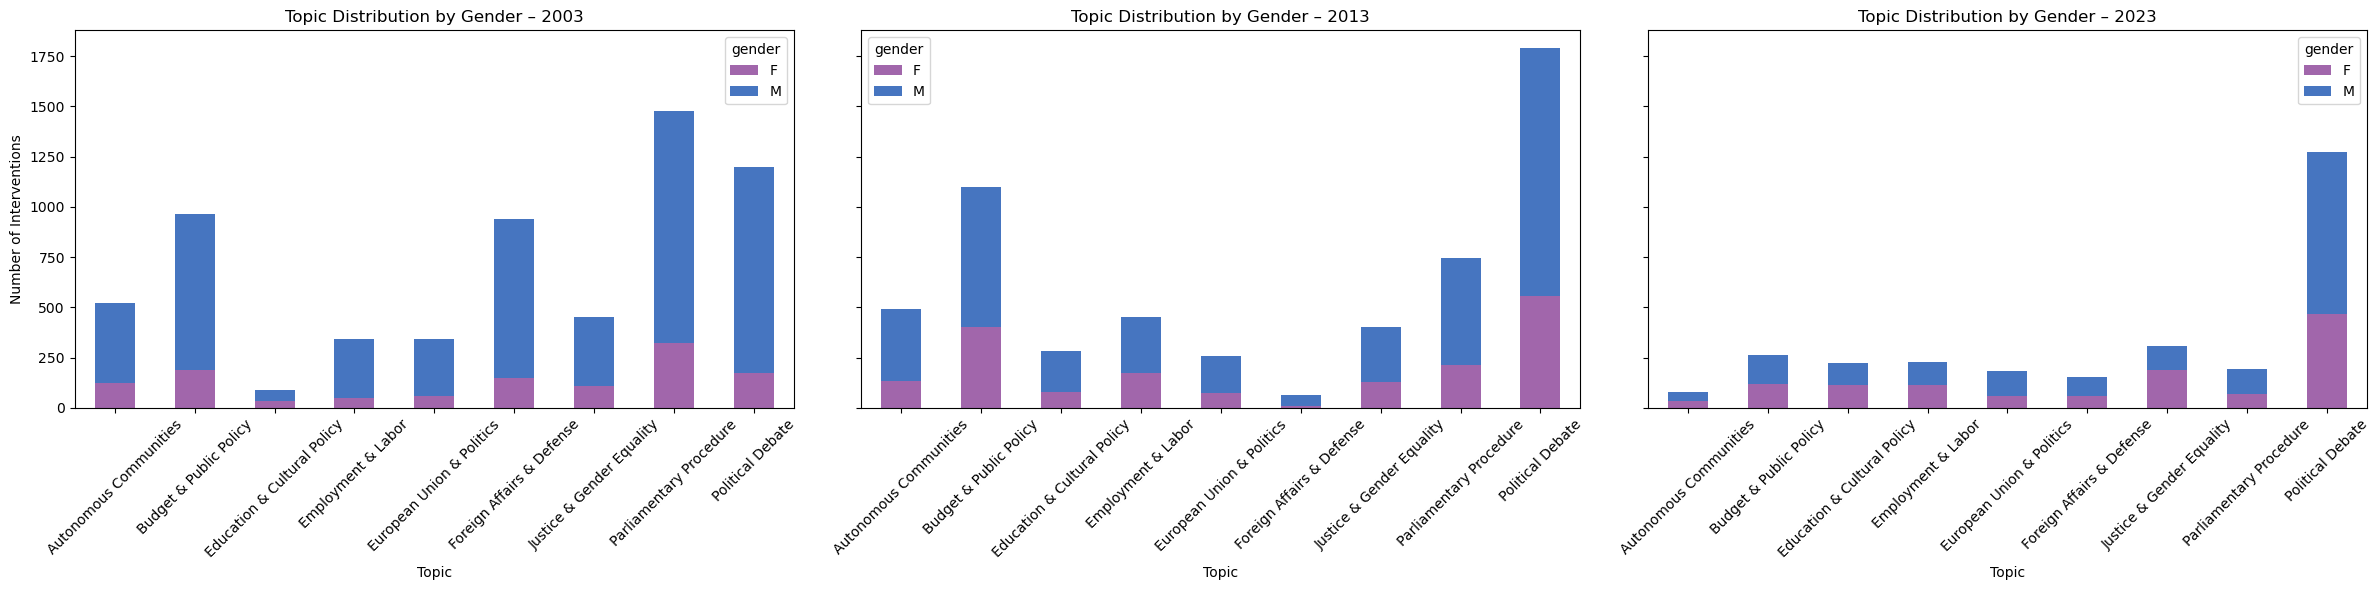

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
# Regenerate the grouped data
topic_year_gender = df.groupby(["year", "topic_label", "gender"]).size().unstack(fill_value=0)

# Plot one chart per year
fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)

colors = {"F": "#A166AB", "M": "#4675C0"}  # purple for women, blue for men

for idx, year in enumerate([2003, 2013, 2023]):
    ax = axes[idx]
    data = topic_year_gender.loc[year]
    data.plot(kind="bar", stacked=True, color=[colors.get(g, "#888") for g in data.columns], ax=ax)
    ax.set_title(f"Topic Distribution by Gender – {year}")
    ax.set_xlabel("Topic")
    ax.set_ylabel("Number of Interventions" if idx == 0 else "")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


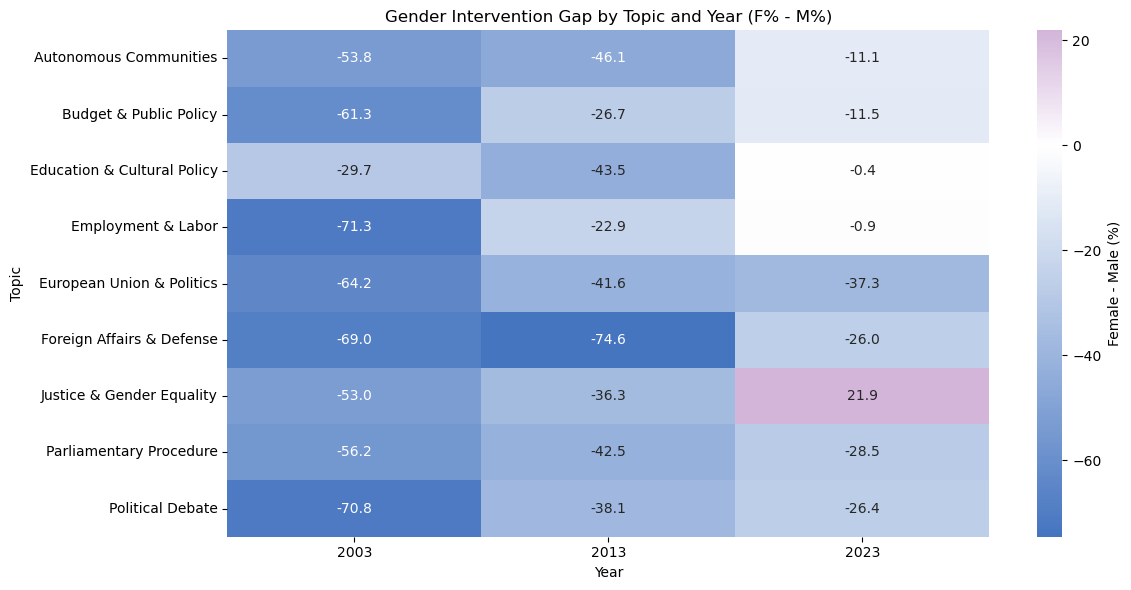

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

percent_by_gender = df.groupby(["year", "topic_label", "gender"]).size().unstack().fillna(0)
percent_by_gender["total"] = percent_by_gender.sum(axis=1)
percent_by_gender["%_F"] = (percent_by_gender["F"] / percent_by_gender["total"]) * 100
percent_by_gender["%_M"] = (percent_by_gender["M"] / percent_by_gender["total"]) * 100
percent_by_gender["gap"] = percent_by_gender["%_F"] - percent_by_gender["%_M"]

# Pivot for heatmap (topics = rows, years = columns)
gap_pivot = percent_by_gender.reset_index().pivot(index="topic_label", columns="year", values="gap")


custom_cmap = LinearSegmentedColormap.from_list(
    "blue_purple_strong", 
    ["#4675C0", "#FFFFFF", "#690380"],  # blue → white → purple
    N=256
)


plt.figure(figsize=(12, 6))
sns.heatmap(
    gap_pivot,
    annot=True,
    fmt=".1f",
    cmap=custom_cmap,
    center=0,
    cbar_kws={"label": "Female - Male (%)"}
)
plt.title("Gender Intervention Gap by Topic and Year (F% - M%)")
plt.xlabel("Year")
plt.ylabel("Topic")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


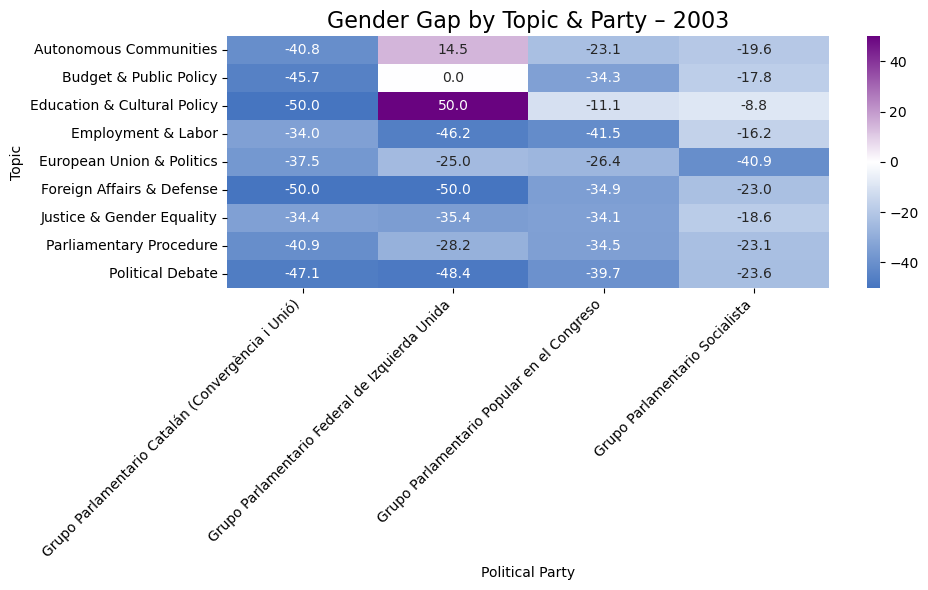

In [22]:
selected_2003 = [
    "Grupo Parlamentario Popular en el Congreso",
    "Grupo Parlamentario Socialista",
    "Grupo Parlamentario Catalán (Convergència i Unió)",
    "Grupo Parlamentario Federal de Izquierda Unida"
]

df_2003 = df[(df["year"] == 2003) & (df["grupo"].isin(selected_2003))]

gap_2003 = (
    df_2003.groupby(["grupo", "topic_label", "gender"])
    .size()
    .unstack(fill_value=0)
)
gap_2003["gap"] = (gap_2003["F"] / (gap_2003["F"] + gap_2003["M"])) * 100 - 50
heatmap_2003 = gap_2003.reset_index().pivot(index="topic_label", columns="grupo", values="gap")

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_2003, annot=True, fmt=".1f", cmap=custom_cmap, center=0, cbar=True)
plt.title("Gender Gap by Topic & Party – 2003", fontsize=16)
plt.xlabel("Political Party")
plt.ylabel("Topic")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


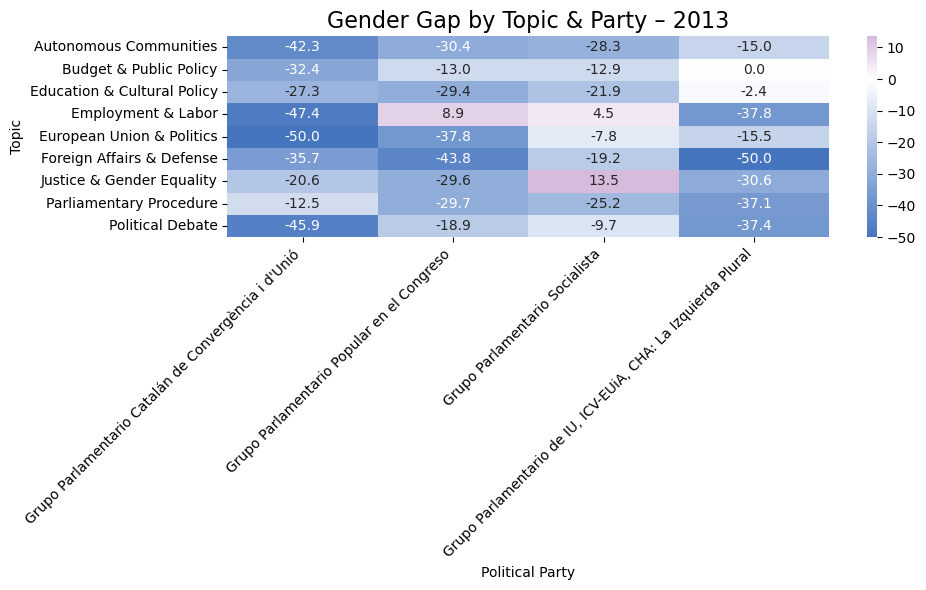

In [23]:
selected_2013 = [
    "Grupo Parlamentario Popular en el Congreso",
    "Grupo Parlamentario Socialista",
    "Grupo Parlamentario Catalán de Convergència i d'Unió",
    "Grupo Parlamentario de IU, ICV-EUiA, CHA: La Izquierda Plural"
]

df_2013 = df[(df["year"] == 2013) & (df["grupo"].isin(selected_2013))]

gap_2013 = (
    df_2013.groupby(["grupo", "topic_label", "gender"])
    .size()
    .unstack(fill_value=0)
)
gap_2013["gap"] = (gap_2013["F"] / (gap_2013["F"] + gap_2013["M"])) * 100 - 50
heatmap_2013 = gap_2013.reset_index().pivot(index="topic_label", columns="grupo", values="gap")

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_2013, annot=True, fmt=".1f", cmap=custom_cmap, center=0, cbar=True)
plt.title("Gender Gap by Topic & Party – 2013", fontsize=16)
plt.xlabel("Political Party")
plt.ylabel("Topic")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


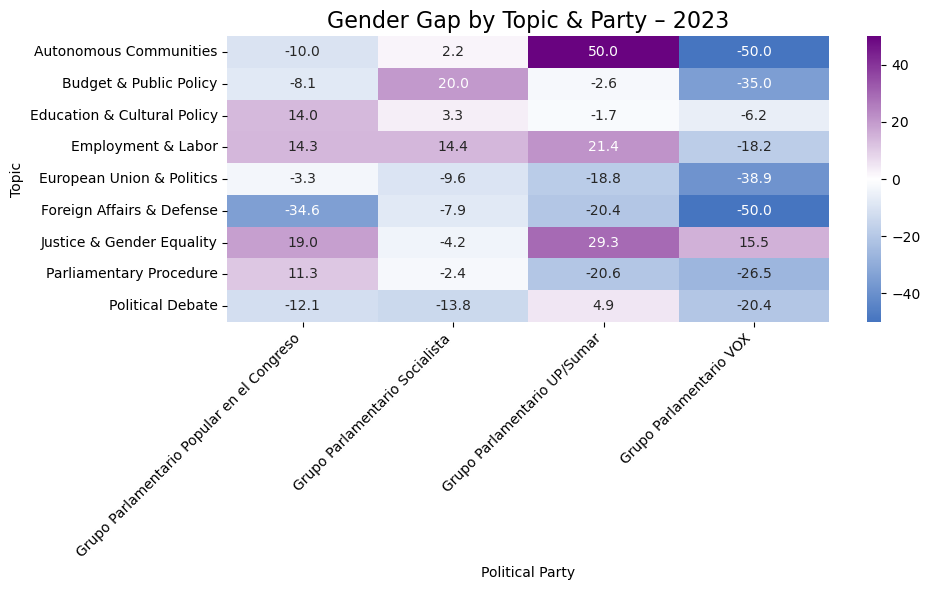

In [24]:
# Merge Podemos and Sumar
df_2023 = df[df["year"] == 2023].copy()
df_2023["grupo"] = df_2023["grupo"].replace({
    "Grupo Parlamentario Confederal de Unidas Podemos-En Comú Podem-Galicia en Común": "Grupo Parlamentario UP/Sumar",
    "Grupo Parlamentario Plurinacional SUMAR": "Grupo Parlamentario UP/Sumar"
})

selected_2023 = [
    "Grupo Parlamentario Popular en el Congreso",
    "Grupo Parlamentario Socialista",
    "Grupo Parlamentario UP/Sumar",
    "Grupo Parlamentario VOX"
]

df_2023 = df_2023[df_2023["grupo"].isin(selected_2023)]

gap_2023 = (
    df_2023.groupby(["grupo", "topic_label", "gender"])
    .size()
    .unstack(fill_value=0)
)
gap_2023["gap"] = (gap_2023["F"] / (gap_2023["F"] + gap_2023["M"])) * 100 - 50
heatmap_2023 = gap_2023.reset_index().pivot(index="topic_label", columns="grupo", values="gap")

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_2023, annot=True, fmt=".1f", cmap=custom_cmap, center=0, cbar=True)
plt.title("Gender Gap by Topic & Party – 2023", fontsize=16)
plt.xlabel("Political Party")
plt.ylabel("Topic")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [25]:
# Count how many interventions belong to each topic (across all years)
topic_counts = df['topic_label'].value_counts().reset_index()
topic_counts.columns = ['Topic', 'Number of Interventions']

# Display the ordered list
display(topic_counts)


,Topic,Number of Interventions
0,Political Debate,4264
1,Parliamentary Procedure,2415
2,Budget & Public Policy,2324
3,Justice & Gender Equality,1163
4,Foreign Affairs & Defense,1158
5,Autonomous Communities,1095
6,Employment & Labor,1021
7,European Union & Politics,783
8,Education & Cultural Policy,597
